# Fine-Tune G3 Report Generator on MIMIC-CXR Impressions


In [ ]:
!pip install -q datasets transformers[torch] accelerate nltk rouge-score Pillow evaluate

import torch
print(f"PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch 2.10.0+cu128  |  CUDA: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

In [ ]:
import os

#  Paths
SAVE_DIR = "/content/drive/MyDrive/g3_finetuned"
CKPT_DIR = "/content/g3_checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)
os.makedirs(CKPT_DIR, exist_ok=True)

# ── Model ──
MODEL_NAME = "IAMJB/chexpert-mimic-cxr-impression-baseline"

#  Data
DATASET_NAME = "itsanmolgupta/mimic-cxr-dataset"
NUM_SAMPLES  = 15_000
VAL_RATIO    = 0.1
MAX_TARGET_LENGTH = 128

#  Training
EPOCHS        = 5
BATCH_SIZE    = 16
GRAD_ACCUM    = 4
LR            = 5e-5
WARMUP_RATIO  = 0.05
WEIGHT_DECAY  = 0.01
FP16          = True
SEED          = 42

print(f"Model:     {MODEL_NAME}")
print(f"Dataset:   {DATASET_NAME}  ({NUM_SAMPLES} samples)")
print(f"Train/Val: {int(NUM_SAMPLES*(1-VAL_RATIO))} / {int(NUM_SAMPLES*VAL_RATIO)}")
print(f"Epochs:    {EPOCHS}   Effective batch: {BATCH_SIZE * GRAD_ACCUM}")
print(f"Save to:   {SAVE_DIR}")

Model:     IAMJB/chexpert-mimic-cxr-impression-baseline
Dataset:   itsanmolgupta/mimic-cxr-dataset  (15000 samples)
Train/Val: 13500 / 1500
Epochs:    5   Effective batch: 64
Save to:   /content/drive/MyDrive/g3_finetuned


## 3. Load Dataset (15k image–impression pairs)

In [ ]:
from datasets import load_dataset
import random

print(f"Loading {DATASET_NAME} ...")
ds = load_dataset(DATASET_NAME)
print(ds)

# Get the available split
if isinstance(ds, dict):
    split_name = list(ds.keys())[0]
    full_dataset = ds[split_name]
else:
    full_dataset = ds

print(f"\nColumns: {full_dataset.column_names}")
print(f"Total available: {len(full_dataset)}")

# Show first sample to identify columns
sample = full_dataset[0]
for col in full_dataset.column_names:
    val = sample[col]
    if isinstance(val, str):
        print(f"  {col}: {val[:120]}...")
    else:
        print(f"  {col}: {type(val).__name__}")

Loading itsanmolgupta/mimic-cxr-dataset ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/357 [00:00<?, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/396M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/397M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/30633 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'findings', 'impression'],
        num_rows: 30633
    })
})

Columns: ['image', 'findings', 'impression']
Total available: 30633
  image: JpegImageFile
  findings: The lungs are clear of focal consolidation, pleural effusion or pneumothorax. The heart size is normal. The mediastinal ...
  impression: No acute cardiopulmonary process....


In [ ]:
#  Identify columns
image_col = None
impression_col = None

for col in full_dataset.column_names:
    if image_col is None and any(k in col.lower() for k in ['image', 'img', 'pixel']):
        image_col = col
    if impression_col is None and 'impression' in col.lower():
        impression_col = col

# Fallback for impression
if impression_col is None:
    for col in full_dataset.column_names:
        if any(k in col.lower() for k in ['report', 'text', 'caption']):
            impression_col = col
            break

assert image_col is not None, f"No image column found in {full_dataset.column_names}"
assert impression_col is not None, f"No impression column found in {full_dataset.column_names}"

print(f"Image column:      '{image_col}'")
print(f"Impression column: '{impression_col}'")

Image column:      'image'
Impression column: 'impression'


In [ ]:
print("Filtering valid samples (non-empty impressions)...")

valid_indices = []
for i in range(len(full_dataset)):
    imp = full_dataset[i][impression_col]
    if imp and isinstance(imp, str) and len(imp.strip()) > 5:
        valid_indices.append(i)
    if len(valid_indices) >= NUM_SAMPLES * 2:
        break

print(f"Found {len(valid_indices)} valid samples")

# Take exactly NUM_SAMPLES
random.seed(SEED)
if len(valid_indices) > NUM_SAMPLES:
    valid_indices = random.sample(valid_indices, NUM_SAMPLES)
else:
    NUM_SAMPLES = len(valid_indices)
    print(f"Only {NUM_SAMPLES} valid samples available, using all")

subset = full_dataset.select(valid_indices)
print(f"Selected {len(subset)} samples")

#  Train / Val split
split = subset.train_test_split(test_size=VAL_RATIO, seed=SEED)
train_ds = split["train"]
val_ds   = split["test"]
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")

Filtering valid samples (non-empty impressions)...
Found 30000 valid samples
Selected 15000 samples
Train: 13500  |  Val: 1500


## 4. Load Pretrained Model & Processor

In [ ]:
from transformers import (
    VisionEncoderDecoderModel,
    ViTImageProcessor,
    BertTokenizer,
)

print(f"Downloading model: {MODEL_NAME}")
model     = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
processor = ViTImageProcessor.from_pretrained(MODEL_NAME)

# Set token IDs on model config (needed for loss computation)
model.config.decoder_start_token_id = tokenizer.cls_token_id
model.config.pad_token_id           = tokenizer.pad_token_id
model.config.eos_token_id           = tokenizer.sep_token_id

# Set generation parameters on generation_config (NOT model.config)
model.generation_config.max_length      = MAX_TARGET_LENGTH
model.generation_config.num_beams       = 4
model.generation_config.early_stopping  = True
model.generation_config.pad_token_id    = tokenizer.pad_token_id
model.generation_config.eos_token_id    = tokenizer.sep_token_id
model.generation_config.decoder_start_token_id = tokenizer.cls_token_id

total_params = sum(p.numel() for p in model.parameters()) / 1e6
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6
print(f"Total params:     {total_params:.1f}M")
print(f"Trainable params: {train_params:.1f}M")
print(f"Decoder start ID: {model.config.decoder_start_token_id}")
print(f"Pad token ID:     {model.config.pad_token_id}")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/271M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/300 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/131 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/590 [00:00<?, ?B/s]

Total params:     67.8M
Trainable params: 67.8M
Decoder start ID: 0
Pad token ID:     1


## 5. Prepare Dataset for Training

In [ ]:
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class CXRReportDataset(Dataset):
    """
    Wraps a HuggingFace dataset for ViT-BERT fine-tuning.
    Returns pixel_values (from ViTImageProcessor) and tokenized labels.
    """
    def __init__(self, hf_dataset, processor, tokenizer, image_col, text_col, max_length=128):
        self.dataset   = hf_dataset
        self.processor = processor
        self.tokenizer = tokenizer
        self.image_col = image_col
        self.text_col  = text_col
        self.max_length = max_length

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]
        image  = sample[self.image_col]
        text   = sample[self.text_col]

        # Handle image
        if not isinstance(image, Image.Image):
            # If stored as path, bytes, or array — convert
            if isinstance(image, str):
                image = Image.open(image)
            elif isinstance(image, np.ndarray):
                image = Image.fromarray(image)
            elif isinstance(image, bytes):
                import io
                image = Image.open(io.BytesIO(image))

        image = image.convert("RGB")

        # Process image → pixel_values [3, H, W]
        pixel_values = self.processor(images=image, return_tensors="pt").pixel_values.squeeze(0)

        # Tokenize text → input_ids for decoder (labels)
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        labels = encoding.input_ids.squeeze(0)
        # Replace pad tokens with -100 so they're ignored in loss
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            "pixel_values": pixel_values,
            "labels": labels,
        }

# Build datasets
train_dataset = CXRReportDataset(train_ds, processor, tokenizer, image_col, impression_col, MAX_TARGET_LENGTH)
val_dataset   = CXRReportDataset(val_ds, processor, tokenizer, image_col, impression_col, MAX_TARGET_LENGTH)

# Quick sanity check
sample = train_dataset[0]
print(f"pixel_values: {sample['pixel_values'].shape}")
print(f"labels shape: {sample['labels'].shape}")
print(f"Non-padding tokens: {(sample['labels'] != -100).sum().item()}")

# Decode the labels to verify
label_ids = sample['labels'].clone()
label_ids[label_ids == -100] = tokenizer.pad_token_id
decoded = tokenizer.decode(label_ids, skip_special_tokens=True)
print(f"Decoded label: {decoded[:200]}")

pixel_values: torch.Size([3, 224, 224])
labels shape: torch.Size([128])
Non-padding tokens: 7
Decoded label: cardiomegaly with mild edema.


## 6. Training Setup

In [ ]:
from transformers import Seq2SeqTrainer, Seq2SeqTrainingArguments
import nltk
import numpy as np

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Metric computation ──
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

smoother = SmoothingFunction().method1
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

def compute_metrics(eval_pred):
    """Compute BLEU-4 and ROUGE-L during evaluation."""
    predictions, label_ids = eval_pred

    # Decode predictions
    pred_ids = predictions
    # Replace -100 in labels
    label_ids = np.where(label_ids != -100, label_ids, tokenizer.pad_token_id)

    pred_texts = tokenizer.batch_decode(pred_ids, skip_special_tokens=True)
    label_texts = tokenizer.batch_decode(label_ids, skip_special_tokens=True)

    bleu4_scores = []
    rouge_l_scores = []

    for pred, ref in zip(pred_texts, label_texts):
        pred = pred.strip()
        ref = ref.strip()
        if len(pred) == 0 or len(ref) == 0:
            bleu4_scores.append(0.0)
            rouge_l_scores.append(0.0)
            continue

        # BLEU-4
        try:
            b4 = sentence_bleu(
                [word_tokenize(ref.lower())],
                word_tokenize(pred.lower()),
                weights=(0.25, 0.25, 0.25, 0.25),
                smoothing_function=smoother
            )
        except:
            b4 = 0.0
        bleu4_scores.append(b4)

        # ROUGE-L
        sc = rouge.score(ref, pred)
        rouge_l_scores.append(sc['rougeL'].fmeasure)

    return {
        "bleu4": np.mean(bleu4_scores),
        "rougeL": np.mean(rouge_l_scores),
    }

In [ ]:
# ── Data collator ──
from dataclasses import dataclass
from typing import Any, Dict, List

@dataclass
class DataCollator:
    """Simple collator that stacks pixel_values and labels."""
    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, Any]:
        pixel_values = torch.stack([f["pixel_values"] for f in features])
        labels       = torch.stack([f["labels"] for f in features])
        return {"pixel_values": pixel_values, "labels": labels}

data_collator = DataCollator()

In [ ]:
# ── Training arguments ──
training_args = Seq2SeqTrainingArguments(
    output_dir=CKPT_DIR,

    # Training
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    lr_scheduler_type="cosine",
    fp16=FP16,

    # Evaluation
    eval_strategy="epoch",
    predict_with_generate=True,              # Use model.generate() for eval metrics
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,

    # Saving
    save_strategy="epoch",
    save_total_limit=2,                      # Keep best + last
    load_best_model_at_end=True,
    metric_for_best_model="rougeL",
    greater_is_better=True,

    # Logging
    logging_steps=50,
    report_to="none",                        # No wandb

    # Misc
    seed=SEED,
    dataloader_num_workers=2,
    remove_unused_columns=False,
)

print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"Total training steps: ~{len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM) * EPOCHS}")
print(f"Eval after each epoch with beam search (num_beams=4)")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Effective batch size: 64
Total training steps: ~1050
Eval after each epoch with beam search (num_beams=4)


## 7. Train

In [ ]:
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("Starting fine-tuning...")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Val samples:   {len(val_dataset)}")
print(f"  Epochs:        {EPOCHS}")
print()

train_result = trainer.train()

Starting fine-tuning...
  Train samples: 13500
  Val samples:   1500
  Epochs:        5



Epoch,Training Loss,Validation Loss,Bleu4,Rougel
1,10.388024,2.422705,0.072626,0.214829
2,11.663309,2.654675,0.086577,0.221817
3,11.507896,2.761303,0.088698,0.219738
4,12.032137,2.865585,0.088810,0.219188
5,12.139496,2.886666,0.088275,0.217753


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['decoder.bert.embeddings.LayerNorm.weight', 'decoder.bert.embeddings.LayerNorm.bias', 'decoder.bert.encoder.layer.0.attention.output.LayerNorm.weight', 'decoder.bert.encoder.layer.0.attention.output.LayerNorm.bias', 'decoder.bert.encoder.layer.0.crossattention.output.LayerNorm.weight', 'decoder.bert.encoder.layer.0.crossattention.output.LayerNorm.bias', 'decoder.bert.encoder.layer.0.output.LayerNorm.weight', 'decoder.bert.encoder.layer.0.output.LayerNorm.bias', 'decoder.bert.encoder.layer.1.attention.output.LayerNorm.weight', 'decoder.bert.encoder.layer.1.attention.output.LayerNorm.bias', 'decoder.bert.encoder.layer.1.crossattention.output.LayerNorm.weight', 'decoder.bert.encoder.layer.1.crossattention.output.LayerNorm.bias', 'decoder.bert.encoder.layer.1.output.LayerNorm.weight', 'decoder.bert.encoder.layer.1.output.LayerNorm.bias', 'decoder.lm_head.decoder.weight', 'decoder.lm_head.decoder.bias'].
There were unexpected keys in 

In [ ]:
# Print training summary
print("\n" + "=" * 60)
print("  Training Complete")
print("=" * 60)
metrics = train_result.metrics
for k, v in sorted(metrics.items()):
    print(f"  {k}: {v}")


  Training Complete
  epoch: 5.0
  total_flos: 3.02710344943104e+18
  train_loss: 11.298289117315933
  train_runtime: 639.0639
  train_samples_per_second: 105.623
  train_steps_per_second: 1.651


## 8. Evaluate on Validation Set

In [ ]:
print("Running final evaluation on validation set...")
eval_metrics = trainer.evaluate()

print("\n" + "=" * 60)
print("  Validation Results")
print("=" * 60)
for k, v in sorted(eval_metrics.items()):
    if isinstance(v, float):
        print(f"  {k:<30}: {v:.4f}")
    else:
        print(f"  {k:<30}: {v}")

Running final evaluation on validation set...



  Validation Results
  epoch                         : 5.0000
  eval_bleu4                    : 0.0857
  eval_loss                     : 2.6565
  eval_rougeL                   : 0.2216
  eval_runtime                  : 22.7038
  eval_samples_per_second       : 66.0680
  eval_steps_per_second         : 4.1400


## 9. Generate Sample Reports (Before vs After)

In [ ]:
import random

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("=" * 70)
print("  Sample Reports: Fine-tuned Model vs Ground Truth")
print("=" * 70)

random.seed(SEED)
sample_indices = random.sample(range(len(val_dataset)), min(10, len(val_dataset)))

for idx in sample_indices:
    sample = val_dataset[idx]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)

    # Ground truth
    gt_ids = sample["labels"].clone()
    gt_ids[gt_ids == -100] = tokenizer.pad_token_id
    gt_text = tokenizer.decode(gt_ids, skip_special_tokens=True)

    # Generate
    with torch.no_grad():
        output_ids = model.generate(
            pixel_values,
            max_length=MAX_TARGET_LENGTH,
            num_beams=4,
            early_stopping=True,
        )
    pred_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print(f"\n--- Sample {idx} ---")
    print(f"  Ground Truth: {gt_text[:200]}")
    print(f"  Generated:    {pred_text[:200]}")

  Sample Reports: Fine-tuned Model vs Ground Truth

--- Sample 1309 ---
  Ground Truth: lower left lateral hemithorax not fully included on the image, however, difficult to exclude nondisplaced fractures involving the lateral left and 8th ribs. bilateral calcified pleural plaques suggest
  Generated:    mild pulmonary edema. no acute cardiopulmonary process.

--- Sample 228 ---
  Ground Truth: no focal consolidation.
  Generated:    ng tube terminates in the stomach. no acute cardiopulmonary process.

--- Sample 51 ---
  Ground Truth: severe, likely non - cardiogenic pulmonary edema or drug reaction, worsened overnight. infection alone is not likely to have progressed in this fashion, and cardiogenic pulmonary edema is less likely 
  Generated:    moderate to severe pulmonary edema with small bilateral pleural effusions and bibasilar atelectasis. no pneumothorax.

--- Sample 563 ---
  Ground Truth: slight blunting of the left costophrenic angle may be due to a trace pleural effusion. n

## 10. Full BLEU & ROUGE Evaluation

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from tqdm.auto import tqdm

smoother = SmoothingFunction().method1
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

model.eval()

all_preds = []
all_refs  = []

print(f"Generating reports for {len(val_dataset)} validation samples...")

for i in tqdm(range(0, len(val_dataset), BATCH_SIZE)):
    batch_pv = []
    batch_gt = []

    for j in range(i, min(i + BATCH_SIZE, len(val_dataset))):
        sample = val_dataset[j]
        batch_pv.append(sample["pixel_values"])
        gt_ids = sample["labels"].clone()
        gt_ids[gt_ids == -100] = tokenizer.pad_token_id
        batch_gt.append(tokenizer.decode(gt_ids, skip_special_tokens=True))

    pixel_values = torch.stack(batch_pv).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            pixel_values,
            max_length=MAX_TARGET_LENGTH,
            num_beams=4,
            early_stopping=True,
        )

    preds = tokenizer.batch_decode(output_ids, skip_special_tokens=True)
    all_preds.extend(preds)
    all_refs.extend(batch_gt)

# Compute all metrics
bleu_scores = {f"BLEU-{n}": [] for n in range(1, 5)}
rouge_scores = {"ROUGE-1": [], "ROUGE-2": [], "ROUGE-L": []}

for pred, ref in zip(all_preds, all_refs):
    pred_tok = word_tokenize(pred.lower().strip())
    ref_tok  = word_tokenize(ref.lower().strip())

    if len(pred_tok) == 0 or len(ref_tok) == 0:
        for n in range(1, 5): bleu_scores[f"BLEU-{n}"].append(0.0)
        for k in rouge_scores: rouge_scores[k].append(0.0)
        continue

    for n in range(1, 5):
        w = tuple([1.0/n]*n + [0.0]*(4-n))
        bleu_scores[f"BLEU-{n}"].append(
            sentence_bleu([ref_tok], pred_tok, weights=w, smoothing_function=smoother)
        )

    sc = scorer.score(ref, pred)
    rouge_scores["ROUGE-1"].append(sc['rouge1'].fmeasure)
    rouge_scores["ROUGE-2"].append(sc['rouge2'].fmeasure)
    rouge_scores["ROUGE-L"].append(sc['rougeL'].fmeasure)

import numpy as np

print("\n" + "=" * 50)
print("  Fine-tuned G3 — Full Validation Metrics")
print("=" * 50)
print(f"  {'Metric':<20} {'Score'}")
print(f"  {'─'*35}")

all_metrics = {}
for k in ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']:
    val = np.mean(bleu_scores[k])
    all_metrics[k] = val
    print(f"  {k:<20} {val:.4f}")
for k in ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']:
    val = np.mean(rouge_scores[k])
    all_metrics[k] = val
    print(f"  {k+' (F1)':<20} {val:.4f}")

avg_len = np.mean([len(p.split()) for p in all_preds])
all_metrics["avg_length"] = avg_len
print(f"  {'Avg Length':<20} {avg_len:.1f} words")

Generating reports for 1500 validation samples...


  0%|          | 0/94 [00:00<?, ?it/s]


  Fine-tuned G3 — Full Validation Metrics
  Metric               Score
  ───────────────────────────────────
  BLEU-1               0.2197
  BLEU-2               0.1415
  BLEU-3               0.1063
  BLEU-4               0.0857
  ROUGE-1 (F1)         0.2362
  ROUGE-2 (F1)         0.1250
  ROUGE-L (F1)         0.2216
  Avg Length           8.2 words


## 11. Save Fine-tuned Model to Drive

In [ ]:
import json

print(f"Saving fine-tuned model to: {SAVE_DIR}")

# Save model + tokenizer + processor
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
processor.save_pretrained(SAVE_DIR)

# Save metrics
metrics_path = os.path.join(SAVE_DIR, "finetune_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump({
        "settings": {
            "base_model": MODEL_NAME,
            "dataset": DATASET_NAME,
            "num_samples": NUM_SAMPLES,
            "train_size": len(train_dataset),
            "val_size": len(val_dataset),
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "grad_accum": GRAD_ACCUM,
            "lr": LR,
            "seed": SEED,
        },
        "metrics": {k: round(v, 4) for k, v in all_metrics.items()},
    }, f, indent=2)

print(f"\nSaved:")
print(f"  Model:   {SAVE_DIR}/")
for f_name in os.listdir(SAVE_DIR):
    size = os.path.getsize(os.path.join(SAVE_DIR, f_name)) / 1e6
    print(f"    {f_name}  ({size:.1f} MB)")
print(f"  Metrics: {metrics_path}")

Saving fine-tuned model to: /content/drive/MyDrive/g3_finetuned


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Saved:
  Model:   /content/drive/MyDrive/g3_finetuned/
    config.json  (0.1 MB)
    generation_config.json  (0.0 MB)
    model.safetensors  (271.1 MB)
    tokenizer_config.json  (0.0 MB)
    tokenizer.json  (0.5 MB)
    preprocessor_config.json  (0.0 MB)
    finetune_metrics.json  (0.0 MB)
  Metrics: /content/drive/MyDrive/g3_finetuned/finetune_metrics.json


## 12. How to Load the Fine-tuned Model Later

In [ ]:
# ── Copy this into your inference notebook / CausalTriGAN pipeline ──

_demo_code = '''
from transformers import VisionEncoderDecoderModel, ViTImageProcessor, BertTokenizer

# Load fine-tuned model from Drive
FINETUNED_PATH = "/content/drive/MyDrive/g3_finetuned"

g3_model     = VisionEncoderDecoderModel.from_pretrained(FINETUNED_PATH).to("cuda").eval()
g3_tokenizer = BertTokenizer.from_pretrained(FINETUNED_PATH)
g3_processor = ViTImageProcessor.from_pretrained(FINETUNED_PATH)

# Generate report from a CXR image (PIL or tensor)
pixel_values = g3_processor(images=pil_image, return_tensors="pt").pixel_values.to("cuda")
output_ids   = g3_model.generate(pixel_values, max_length=128, num_beams=4, early_stopping=True)
report       = g3_tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(report)
'''

print("To load the fine-tuned model in another notebook:")
print(_demo_code)

To load the fine-tuned model in another notebook:

from transformers import VisionEncoderDecoderModel, ViTImageProcessor, BertTokenizer

# Load fine-tuned model from Drive
FINETUNED_PATH = "/content/drive/MyDrive/g3_finetuned"

g3_model     = VisionEncoderDecoderModel.from_pretrained(FINETUNED_PATH).to("cuda").eval()
g3_tokenizer = BertTokenizer.from_pretrained(FINETUNED_PATH)
g3_processor = ViTImageProcessor.from_pretrained(FINETUNED_PATH)

# Generate report from a CXR image (PIL or tensor)
pixel_values = g3_processor(images=pil_image, return_tensors="pt").pixel_values.to("cuda")
output_ids   = g3_model.generate(pixel_values, max_length=128, num_beams=4, early_stopping=True)
report       = g3_tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(report)



## 13. Results Visualization

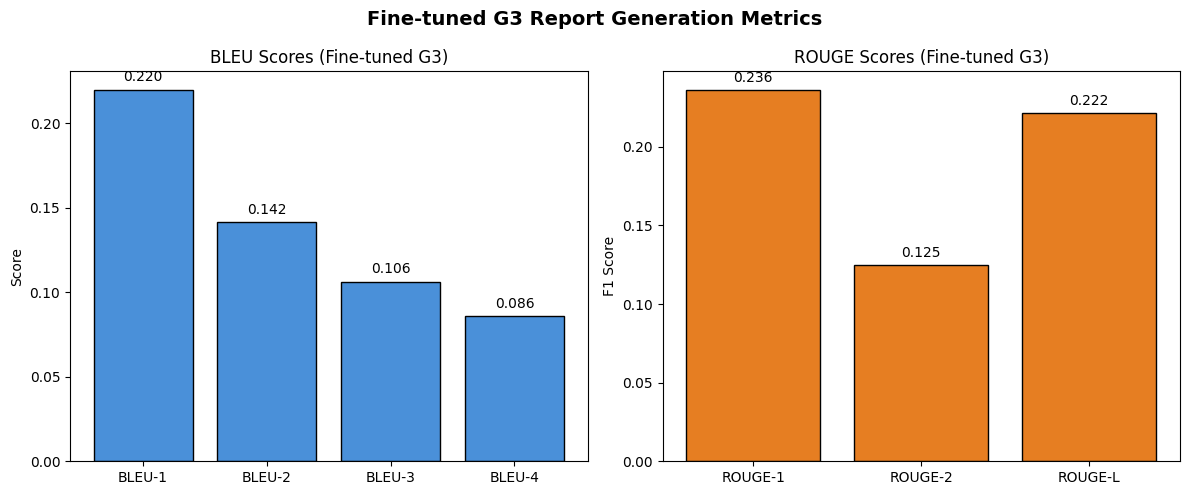

Chart saved: /content/drive/MyDrive/g3_finetuned/finetune_metrics_chart.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# BLEU
bleu_keys = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4']
bleu_vals = [all_metrics[k] for k in bleu_keys]
bars1 = axes[0].bar(bleu_keys, bleu_vals, color='#4A90D9', edgecolor='black')
axes[0].set_ylabel('Score')
axes[0].set_title('BLEU Scores (Fine-tuned G3)')
for bar in bars1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=10)

# ROUGE
rouge_keys = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
rouge_vals = [all_metrics[k] for k in rouge_keys]
bars2 = axes[1].bar(rouge_keys, rouge_vals, color='#E67E22', edgecolor='black')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('ROUGE Scores (Fine-tuned G3)')
for bar in bars2:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=10)

plt.suptitle('Fine-tuned G3 Report Generation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
chart_path = os.path.join(SAVE_DIR, "finetune_metrics_chart.png")
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Chart saved: {chart_path}")